### Pipeline overview (Section 3.2 of the handbook)

```
Raw Fashion-MNIST (28x28 uint8)
      -> preprocessing (Normalize; train split also gets RandomHorizontalFlip + RandomCrop)
      -> ArrayImageDataset / DataLoader (identical for all 5 models)
      -> model (Linear | MLP | CNN | GRU | Transformer -- each reshapes the same batch internally)
      -> CrossEntropyLoss (no softmax applied before the loss)
      -> Adam optimizer + ReduceLROnPlateau scheduler
      -> prediction (argmax over logits)
      -> post-processing (none needed for classification)
      -> evaluation (accuracy, macro-F1, confusion matrix, qualitative examples)
```


In [1]:
# Environment (run once). Uncomment if the packages are not already installed.
!pip install -q torch torchvision scikit-learn matplotlib pandas


In [2]:
import os, time, copy, random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.transforms import InterpolationMode

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


## 0.1 Mount Google Drive and set up output folders

Every figure, trained-model checkpoint, and result table produced by this notebook is written
to `OUTPUT_DIR` on Google Drive (in addition to being shown inline), so nothing is lost if the
Colab runtime disconnects or is reset. Re-running this cell is safe — folders are created only
if they don't already exist.

In [3]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_ROOT = "/content/drive/MyDrive/CO3133_Assignments"
except ImportError:
    print("Not running on Colab — using a local output folder instead of Google Drive.")
    DRIVE_ROOT = "."

OUTPUT_DIR = os.path.join(DRIVE_ROOT, "A1_Foundations_FashionMNIST")
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
CKPT_DIR = os.path.join(OUTPUT_DIR, "checkpoints")
RESULTS_DIR = os.path.join(OUTPUT_DIR, "results")

for d in (FIG_DIR, CKPT_DIR, RESULTS_DIR):
    os.makedirs(d, exist_ok=True)

print("Saving all outputs under:", OUTPUT_DIR)


Mounted at /content/drive
Saving all outputs under: /content/drive/MyDrive/CO3133_Assignments/A1_Foundations_FashionMNIST


In [4]:
# Auto-captured reproducibility info (Section 3.2 / 4.2 of the handbook) --
# reused verbatim in the Reproducibility section at the end, instead of being typed by hand.
import platform

env_info = {
    "seed": SEED,
    "python_version": platform.python_version(),
    "torch_version": torch.__version__,
    "torchvision_version": torchvision.__version__,
    "device": str(DEVICE),
    "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A (CPU run)",
    "platform": platform.platform(),
}
for k, v in env_info.items():
    print(f"{k}: {v}")


seed: 42
python_version: 3.13.15
torch_version: 2.11.0+cu128
torchvision_version: 0.26.0+cu128
device: cuda
gpu_name: Tesla T4
platform: Linux-6.6.122+-x86_64-with-glibc2.39


## 1. Data loading

MNIST is downloaded only to show it is available for early debugging (Section 10, handbook).
All reported results in this notebook use Fashion-MNIST.


In [5]:
mnist_debug_train = torchvision.datasets.MNIST(root="./data", train=True, download=True)
print("MNIST debug set (not reported):", len(mnist_debug_train), "images")

# Main dataset for the assignment
fmnist_train_raw = torchvision.datasets.FashionMNIST(root="./data", train=True, download=True)
fmnist_test_raw = torchvision.datasets.FashionMNIST(root="./data", train=False, download=True)

train_images_all = fmnist_train_raw.data.numpy()      # (60000, 28, 28) uint8
train_labels_all = fmnist_train_raw.targets.numpy()   # (60000,)
test_images = fmnist_test_raw.data.numpy()            # (10000, 28, 28) uint8
test_labels = fmnist_test_raw.targets.numpy()         # (10000,)

print("Fashion-MNIST train+val pool:", train_images_all.shape, train_labels_all.shape)
print("Fashion-MNIST official test :", test_images.shape, test_labels.shape)


100%|██████████| 9.91M/9.91M [00:01<00:00, 4.99MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 128kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.91MB/s]


MNIST debug set (not reported): 60000 images


100%|██████████| 26.4M/26.4M [00:02<00:00, 11.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 166kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.27MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 8.77MB/s]

Fashion-MNIST train+val pool: (60000, 28, 28) (60000,)
Fashion-MNIST official test : (10000, 28, 28) (10000,)


## 2. Exploratory Data Analysis (EDA)

Required for this assignment (Section 13 of the handbook): class distribution, input size,
imbalance analysis, representative samples.


Detected 10 classes from the training data.
   class_id   class_name  train_count  train_pct
0         0  T-shirt/top         6000       10.0
1         1      Trouser         6000       10.0
2         2     Pullover         6000       10.0
3         3        Dress         6000       10.0
4         4         Coat         6000       10.0
5         5       Sandal         6000       10.0
6         6        Shirt         6000       10.0
7         7      Sneaker         6000       10.0
8         8          Bag         6000       10.0
9         9   Ankle boot         6000       10.0

Max/min class count ratio (imbalance ratio): 1.0


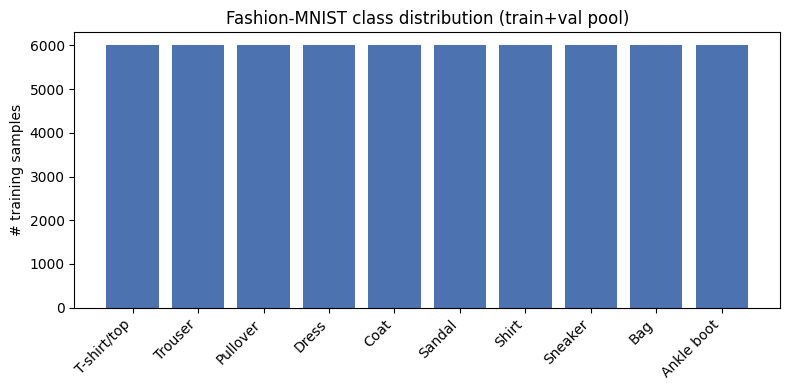

Input size: 28x28 grayscale (1 channel), pixel range [0, 255] as uint8.


In [6]:
# Discover class metadata from the loaded dataset during EDA
class_ids, counts = np.unique(train_labels_all, return_counts=True)
CLASS_NAMES = list(fmnist_train_raw.classes)
NUM_CLASSES = len(class_ids)

if len(CLASS_NAMES) != NUM_CLASSES:
    raise ValueError("Dataset class names do not match the labels found in the training data.")

print(f"Detected {NUM_CLASSES} classes from the training data.")

# Class distribution (imbalance analysis)
dist_df = pd.DataFrame({
    "class_id": class_ids,
    "class_name": CLASS_NAMES,
    "train_count": counts,
})
dist_df["train_pct"] = 100 * dist_df["train_count"] / dist_df["train_count"].sum()
print(dist_df)
print("\nMax/min class count ratio (imbalance ratio):",
      dist_df['train_count'].max() / dist_df['train_count'].min())

plt.figure(figsize=(8, 4))
plt.bar(dist_df["class_name"], dist_df["train_count"], color="#4C72B0")
plt.xticks(rotation=45, ha="right")
plt.ylabel("# training samples")
plt.title("Fashion-MNIST class distribution (train+val pool)")
plt.tight_layout()
plt.show()

print("Input size: 28x28 grayscale (1 channel), pixel range [0, 255] as uint8.")


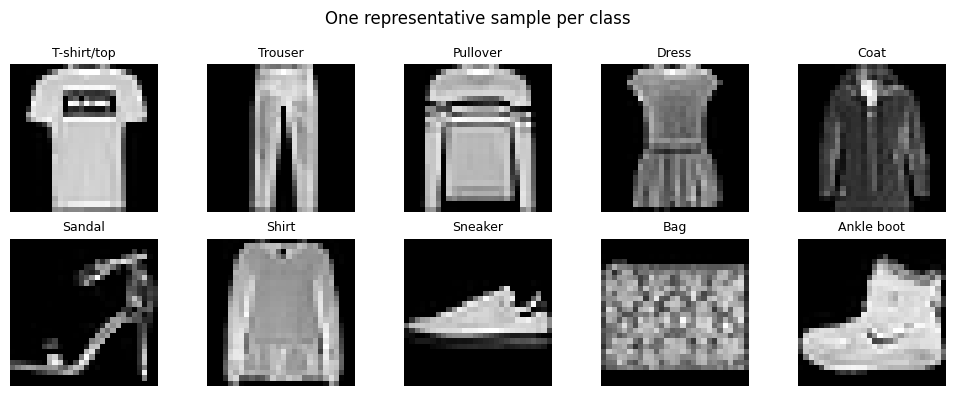

Computed pixel mean = 0.2860, pixel std = 0.3530 (used for Normalize())


In [7]:
# Representative samples: one example per class
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for c in range(NUM_CLASSES):
    idx = np.where(train_labels_all == c)[0][0]
    ax = axes[c // 5, c % 5]
    ax.imshow(train_images_all[idx], cmap="gray")
    ax.set_title(CLASS_NAMES[c], fontsize=9)
    ax.axis("off")
plt.suptitle("One representative sample per class")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "01_eda_representative_samples.png"), dpi=150, bbox_inches="tight")
plt.show()

# Pixel statistics used later for normalization
pixel_mean = (train_images_all / 255.0).mean()
pixel_std = (train_images_all / 255.0).std()
print(f"Computed pixel mean = {pixel_mean:.4f}, pixel std = {pixel_std:.4f} (used for Normalize())")


**[TODO: discuss]** Is the class distribution balanced? Does the imbalance ratio
computed above justify (or not justify) using macro-F1 in addition to accuracy?


## 3. Train / validation / test split

- Official Fashion-MNIST **test** split (10,000 images) is held out untouched and used only for
  final reporting.
- The official **train** pool (60,000 images) is further split into **train** (48,000 — 80%) and
  **val** (12,000 — 20%) with a *stratified* split so every class keeps the same proportion in both
  subsets, using a fixed seed for reproducibility.
- All five models below are trained/evaluated on exactly the same split (fairness constraint,
  Section 12.2 of the handbook).


In [8]:
train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_all)),
    test_size=0.2,  # 80/20 train/val split (48,000 train / 12,000 val)
    stratify=train_labels_all,
    random_state=SEED,
)

train_images, train_labels = train_images_all[train_idx], train_labels_all[train_idx]
val_images, val_labels = train_images_all[val_idx], train_labels_all[val_idx]

print(f"train: {train_images.shape[0]} | val: {val_images.shape[0]} | test: {test_images.shape[0]}")
print("Split seed:", SEED, "| Stratified by label: yes | Split unit: one image = one sample")


train: 48000 | val: 12000 | test: 10000
Split seed: 42 | Stratified by label: yes | Split unit: one image = one sample


## 4. Preprocessing, Dataset and DataLoader

The same `Dataset`/`DataLoader` pipeline feeds all five models — each model reshapes the
flat `(N, 1, 28, 28)` batch internally (flatten, sequence-of-rows, or patches), so the
preprocessing stays identical across models (fairness constraint).

Data augmentation (`RandomHorizontalFlip`, `RandomRotation`, `RandomCrop`, `ColorJitter`) is applied to the
training split only; validation/test use only normalization.


In [9]:
# ==============================================================================
# 4. Custom Dataset & Data Transformations
# ==============================================================================

class ArrayImageDataset(Dataset):
    """
    Dataset nhận mảng NumPy thô và áp dụng transform cho từng mẫu.
    - Input images: ndarray uint8, shape (N, 28, 28) với giá trị [0, 255]
    - Input labels: ndarray int64, shape (N,) với giá trị nhãn [0, 9]
    """
    def __init__(self, images, labels, transform):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        # Trả về tổng số lượng mẫu N
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.fromarray(self.images[idx]).convert("L")
        label = int(self.labels[idx])                       # int scalar: 0 -> 9

        # [Bước 2]: Đi qua chuỗi transform (xem chi tiết kích thước từng bước bên dưới)
        #   - img sau transform: Tensor shape (1, 28, 28), dtype: torch.float32
        return self.transform(img), label


# ------------------------------------------------------------------------------
# Pipeline biến đổi dữ liệu cho tập TRAIN (có Data Augmentation)
# ------------------------------------------------------------------------------
train_transform = transforms.Compose([
    # Input ban đầu: PIL Image, kích thước (28 x 28), 1 channel (mode 'L')

    # Bước 1: Lật ngang ngẫu nhiên với xác suất 50% (giữ tính đối xứng vật lý tự nhiên)
    # -> Dimension: PIL Image vẫn giữ nguyên kích thước (28 x 28)
    transforms.RandomAffine(degrees=7.5, translate=(0.078, 0.075), scale=(0.915, 1.085), interpolation=InterpolationMode.BILINEAR, fill=0),

    # Bước 5: Chuyển PIL Image -> PyTorch Tensor, đồng thời scale pixel từ [0, 255] về [0.0, 1.0]
    # Thêm chiều kênh (channel dimension) ở đầu: (H, W) -> (C, H, W)
    # -> Dimension: torch.FloatTensor shape (1, 28, 28), dtype: torch.float32
    transforms.ToTensor(),

    # Bước 6: Chuẩn hóa Z-score: output = (input - pixel_mean) / pixel_std
    # Giúp dữ liệu có mean ~ 0 và std ~ 1 để gradient ổn định
    # -> Dimension: torch.FloatTensor shape (1, 28, 28) (kích thước không đổi)
    transforms.Normalize((pixel_mean,), (pixel_std,)),
])

# ------------------------------------------------------------------------------
# Pipeline biến đổi dữ liệu cho tập EVALUATION (Val & Test - KHÔNG dùng Augmentation)
# ------------------------------------------------------------------------------
eval_transform = transforms.Compose([
    # Input ban đầu: PIL Image, kích thước (28 x 28)

    # Bước 1: Chuyển PIL Image -> Tensor và scale [0.0, 1.0]
    # -> Dimension: torch.FloatTensor shape (1, 28, 28)
    transforms.ToTensor(),

    # Bước 2: Chuẩn hóa theo cùng mean/std của tập train
    # -> Dimension: torch.FloatTensor shape (1, 28, 28)
    transforms.Normalize((pixel_mean,), (pixel_std,)),
])

# ------------------------------------------------------------------------------
# Khởi tạo Dataset & DataLoader
# ------------------------------------------------------------------------------
BATCH_SIZE = 128

# Khởi tạo các Dataset (Train: 48.000 mẫu | Val: 12.000 mẫu | Test: 10.000 mẫu)
train_ds = ArrayImageDataset(train_images, train_labels, train_transform)
val_ds = ArrayImageDataset(val_images, val_labels, eval_transform)
test_ds = ArrayImageDataset(test_images, test_labels, eval_transform)

# DataLoader thực hiện batching (gom nhóm) các mẫu đơn lẻ thành các mini-batch:
# - train_loader: batch_size = 128 (có shuffle ngẫu nhiên)
# - val_loader & test_loader: batch_size = 256 (không shuffle)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=2)

# [Kiểm tra kích thước đầu ra từ DataLoader]:
# Gom B mẫu (1, 28, 28) -> Tensor (B, 1, 28, 28) với B = BATCH_SIZE = 128
# Gom B nhãn scalar     -> Tensor (B,) gồm 128 số nguyên nhãn [0 -> 9]
xb, yb = next(iter(train_loader))
print("One preprocessed batch image shape:", xb.shape, "| dtype:", xb.dtype)   # torch.Size([128, 1, 28, 28])
print("One preprocessed batch label shape:", yb.shape, "| dtype:", yb.dtype)   # torch.Size([128])


One preprocessed batch image shape: torch.Size([128, 1, 28, 28]) | dtype: torch.float32
One preprocessed batch label shape: torch.Size([128]) | dtype: torch.int64


## 5. Shared training / evaluation utilities

One generic training loop, evaluation function, and metric set is reused for every model so
that all five architectures are trained and compared under an identical protocol.


In [10]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def compute_class_metrics(y_true, y_pred, class_names=CLASS_NAMES):
    """
    Tính toán chi tiết Accuracy, Precision, Recall, F1 cho từng lớp riêng biệt,
    sau đó tổng hợp thành hàng Macro Average ở dòng cuối cùng.
    """
    prec_per_class = precision_score(y_true, y_pred, average=None, zero_division=0)
    rec_per_class = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1_per_class = f1_score(y_true, y_pred, average=None, zero_division=0)

    rows = []
    for c in range(len(class_names)):
        acc_c = ((y_pred == c) == (y_true == c)).mean()  # One-vs-Rest accuracy cho từng lớp
        support_c = (y_true == c).sum()
        rows.append({
            "Class ID": c,
            "Class Name": class_names[c],
            "Accuracy": round(float(acc_c), 4),
            "Precision": round(float(prec_per_class[c]), 4),
            "Recall": round(float(rec_per_class[c]), 4),
            "F1-Score": round(float(f1_per_class[c]), 4),
            "Support": int(support_c),
        })

    df = pd.DataFrame(rows)

    # Dòng tổng hợp Macro Average
    macro_row = pd.DataFrame([{
        "Class ID": "-",
        "Class Name": "Macro Average",
        "Accuracy": round(float(accuracy_score(y_true, y_pred)), 4),
        "Precision": round(float(prec_per_class.mean()), 4),
        "Recall": round(float(rec_per_class.mean()), 4),
        "F1-Score": round(float(f1_per_class.mean()), 4),
        "Support": int(len(y_true)),
    }])

    return pd.concat([df, macro_row], ignore_index=True)


def fit(model, dataloader, criterion, optimizer, device=DEVICE):
    """Huấn luyện mô hình trong một epoch."""
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        all_preds.append(outputs.argmax(dim=1).detach().cpu().numpy())
        all_labels.append(labels.detach().cpu().numpy())

    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_labels)
    epoch_loss = running_loss / len(dataloader.dataset)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    return epoch_loss, acc, prec, rec, macro_f1, y_true, y_pred


@torch.no_grad()
def evaluate(model, dataloader, criterion, device=DEVICE):
    """Đánh giá mô hình trên tập validation hoặc test."""
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        all_preds.append(outputs.argmax(dim=1).detach().cpu().numpy())
        all_labels.append(labels.detach().cpu().numpy())

    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_labels)
    epoch_loss = running_loss / len(dataloader.dataset)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    return epoch_loss, acc, prec, rec, macro_f1, y_true, y_pred


def run_one_epoch(model, train_loader, val_loader, criterion, optimizer, device=DEVICE):
    """Chạy lần lượt fit() cho train và evaluate() cho validation trong một epoch."""
    train_loss, train_acc, train_prec, train_rec, train_f1, _, _ = fit(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_prec, val_rec, val_f1, _, _ = evaluate(model, val_loader, criterion, device)
    return (train_loss, train_acc, train_prec, train_rec, train_f1,
            val_loss, val_acc, val_prec, val_rec, val_f1)


def run_epoch(model, loader, criterion, optimizer=None, desc=None):
    """Hàm wrapper hỗ trợ tương thích với các cell test/eval khác trong notebook."""
    if optimizer is not None:
        return fit(model, loader, criterion, optimizer, DEVICE)
    else:
        return evaluate(model, loader, criterion, DEVICE)


def train_model(model, name, epochs=15, lr=1e-3, patience=3, history=None,
                optimizer_state_dict=None, scheduler_state_dict=None,
                best_val_loss=None, start_epoch=None):
    """Train from scratch or continue from a checkpoint.

    If optimizer/scheduler states are supplied, they are restored. Older checkpoints
    that do not contain them can still continue from the saved model weights with a
    fresh optimizer (use a smaller RESUME_LR in that case).
    """
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3, threshold=1e-4,
        threshold_mode="abs", min_lr=1e-6
    )

    if optimizer_state_dict is not None:
        optimizer.load_state_dict(optimizer_state_dict)
    if scheduler_state_dict is not None:
        scheduler.load_state_dict(scheduler_state_dict)

    if history is None:
        history = {"train_loss": [], "train_acc": [], "train_prec": [], "train_rec": [], "train_f1": [],
                   "val_loss": [], "val_acc": [], "val_prec": [], "val_rec": [], "val_f1": []}
    else:
        history = copy.deepcopy(history)

    start_epoch = len(history.get("train_loss", [])) if start_epoch is None else int(start_epoch)
    if best_val_loss is None:
        best_val_loss = min(history.get("val_loss", [])) if history.get("val_loss") else float("inf")

    best_state = copy.deepcopy(model.state_dict())
    best_optimizer_state = copy.deepcopy(optimizer.state_dict())
    best_scheduler_state = copy.deepcopy(scheduler.state_dict())
    bad_epochs = 0

    t0 = time.time()
    for local_epoch in range(1, epochs + 1):
        train_loss, train_acc, train_prec, train_rec, train_f1, val_loss, val_acc, val_prec, val_rec, val_f1 = run_one_epoch(
            model, train_loader, val_loader, criterion, optimizer, DEVICE
        )
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss); history["train_acc"].append(train_acc)
        history["train_prec"].append(train_prec); history["train_rec"].append(train_rec); history["train_f1"].append(train_f1)
        history["val_loss"].append(val_loss); history["val_acc"].append(val_acc)
        history["val_prec"].append(val_prec); history["val_rec"].append(val_rec); history["val_f1"].append(val_f1)

        epoch = start_epoch + local_epoch
        print(f"[{name}] Epoch {epoch:03d} | Train Loss: {train_loss:.4f} - Acc: {train_acc:.4f} - F1: {train_f1:.4f} | "
              f"Val Loss: {val_loss:.4f} - Acc: {val_acc:.4f} - F1: {val_f1:.4f} | LR: {optimizer.param_groups[0]['lr']:.2e}")

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_optimizer_state = copy.deepcopy(optimizer.state_dict())
            best_scheduler_state = copy.deepcopy(scheduler.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"[{name}] early stopping at epoch {epoch} (best val_loss={best_val_loss:.4f})")
                break

    train_time = time.time() - t0
    model.load_state_dict(best_state)
    optimizer.load_state_dict(best_optimizer_state)
    scheduler.load_state_dict(best_scheduler_state)

    training_state = {
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_val_loss": float(best_val_loss),
        "epochs_run": len(history.get("train_loss", [])),
    }
    return model, history, train_time, training_state

def measure_inference_time(model, loader, n_warmup_batches=2):
    model.eval()
    device_sync = torch.cuda.synchronize if DEVICE.type == "cuda" else (lambda: None)

    with torch.no_grad():
        for i, (xb, _) in enumerate(loader):
            if i >= n_warmup_batches:
                break
            _ = model(xb.to(DEVICE))

    device_sync()
    t0 = time.time()
    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(DEVICE)
            _ = model(xb)
    device_sync()
    total_time = time.time() - t0
    return 1000 * total_time / len(loader.dataset)


## 6. Model 1 — Linear / Softmax classifier

A single linear layer on the flattened pixels. `CrossEntropyLoss` already combines
`log_softmax` + NLL, so softmax must **not** be applied inside the model.


In [11]:
class LinearClassifier(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, input_dim=28 * 28):
        super().__init__()
        self.fc = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.fc(x)  # raw logits, no softmax


## 7. Model 2 — Multilayer Perceptron (MLP)

Flattened pixels through two hidden layers with ReLU activations and dropout regularization.


In [12]:
class MLP(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, input_dim=28 * 28, hidden_dims=(256, 128, 64), dropout=0.3):
        super().__init__()
        layers, prev = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(inplace=True), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)


## 8. Model 3 — Convolutional Neural Network (CNN)

A small custom architecture (not a pretrained backbone, per Section 11.1 of the handbook):
three conv blocks (Conv -> BatchNorm -> ReLU, with two max-pools) that build up spatial
feature maps, followed by global average pooling and a linear classifier head.


In [13]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2),nn.Dropout2d(0.25),   # 28->14
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2),nn.Dropout2d(0.25),  # 14->7
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),nn.Dropout2d(0.3),                 # 7x7 feature maps
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(128, 64), nn.ReLU(inplace=True), nn.Dropout(0.3), nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


## 9. Model 4 — GRU (row-sequence model)

Each 28x28 image is treated as a sequence of **28 timesteps**, one per image row, where each
timestep is a 28-dimensional input vector (the pixel values of that row). A bidirectional GRU
processes the sequence and the final hidden representation is passed to a linear classifier.


In [14]:
# class RowSequenceGRU(nn.Module):
#     def __init__(self, num_classes=NUM_CLASSES, input_size=28, hidden_size=128, num_layers=1):
#         super().__init__()
#         self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers,
#                            batch_first=True, bidirectional=True)
#         out_dim = hidden_size * 2
#         self.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(out_dim, num_classes))

#     def forward(self, x):
#         # x: (N, 1, 28, 28) -> sequence of 28 rows, each row is a 28-dim timestep input
#         x = x.squeeze(1)               # (N, seq_len=28, input_size=28)
#         out, _ = self.gru(x)           # out: (N, seq_len, hidden_size*2)
#         last = out[:, -1, :]           # representation after the last timestep
#         return self.classifier(last)


## 10. Model 5 — Transformer (patch-based)

Each image is split into non-overlapping 4x4 patches (49 patches of 16 pixels each), linearly
projected to `d_model`, prepended with a learnable `[CLS]` token, and given learnable
positional encodings before a standard `TransformerEncoder`. The `[CLS]` output feeds the
classifier head (a ViT-style design, adapted to a small grayscale image).


In [15]:
# class PatchTransformer(nn.Module):
#     def __init__(self, num_classes=NUM_CLASSES, img_size=28, patch_size=4, d_model=64,
#                  nhead=4, num_layers=3, dim_feedforward=128, dropout=0.1):
#         super().__init__()
#         assert img_size % patch_size == 0
#         self.patch_size = patch_size
#         num_patches = (img_size // patch_size) ** 2
#         patch_dim = patch_size * patch_size  # single channel

#         self.patch_embed = nn.Linear(patch_dim, d_model)
#         self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
#         self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, d_model))
#         nn.init.trunc_normal_(self.pos_embed, std=0.02)

#         encoder_layer = nn.TransformerEncoderLayer(
#             d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
#             dropout=dropout, batch_first=True)
#         self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
#         self.norm = nn.LayerNorm(d_model)
#         self.classifier = nn.Linear(d_model, num_classes)

#     def forward(self, x):
#         N, p = x.size(0), self.patch_size
#         patches = x.unfold(2, p, p).unfold(3, p, p)              # (N,1,H/p,W/p,p,p)
#         patches = patches.contiguous().view(N, -1, p * p)         # (N, num_patches, patch_dim)
#         tokens = self.patch_embed(patches)                        # (N, num_patches, d_model) -- token/attention input
#         cls = self.cls_token.expand(N, -1, -1)
#         tokens = torch.cat([cls, tokens], dim=1) + self.pos_embed  # (N, num_patches+1, d_model)
#         out = self.encoder(tokens)                                 # attention output, same shape
#         out = self.norm(out[:, 0])                                 # take the [CLS] token representation
#         return self.classifier(out)


## 11. Checkpoint registry and I/O utilities

This section contains only model/checkpoint utilities. It **does not train anything**. After a runtime restart, evaluation only requires Sections 0–10, this section, and Section 13.

Checkpoint naming remains compatible with the existing files in Google Drive: `CKPT_DIR/<MODEL>_200K_v3.pt`.


In [26]:
import pickle

MODEL_BUILDERS = {
    "Linear": lambda: LinearClassifier(),
    "MLP": lambda: MLP(),
    "CNN": lambda: SimpleCNN(),
    # "GRU": lambda: RowSequenceGRU(),
    # "Transformer": lambda: PatchTransformer(),
}

CHECKPOINT_TAG = "200K_v3"

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

def checkpoint_path(name):
    return os.path.join(CKPT_DIR, f"{name}_{CHECKPOINT_TAG}.pt")

def find_existing_checkpoint(name):
    path = checkpoint_path(name)
    return path if os.path.exists(path) else None

def format_time(seconds):
    seconds = float(seconds)
    if seconds < 60: return f"{seconds:.1f}s"
    minutes, seconds = divmod(seconds, 60)
    if minutes < 60: return f"{int(minutes)}m {seconds:.1f}s"
    hours, minutes = divmod(minutes, 60)
    return f"{int(hours)}h {int(minutes)}m {seconds:.1f}s"

def load_model_checkpoint(name, device=DEVICE):
    """Rebuild architecture + load state_dict. No training and no test inference here."""
    if name not in MODEL_BUILDERS:
        raise ValueError(f"Unknown model '{name}'. Available: {list(MODEL_BUILDERS)}")

    path = find_existing_checkpoint(name)
    if path is None:
        raise FileNotFoundError(f"No checkpoint found for {name}: {checkpoint_path(name)}")

    # These are our own trusted checkpoints and may contain NumPy/Python metadata.
    ckpt = torch.load(path, map_location=device, weights_only=False)
    model = MODEL_BUILDERS[name]().to(device)
    state_dict = ckpt["state_dict"] if isinstance(ckpt, dict) and "state_dict" in ckpt else ckpt

    try:
        model.load_state_dict(state_dict)
    except RuntimeError as e:
        raise RuntimeError(
            f"Checkpoint '{path}' is incompatible with the current {name} architecture. "
            "If the architecture was changed, train a new checkpoint or change CHECKPOINT_TAG.\n"
            f"Original error:\n{e}"
        ) from e

    model.eval()
    return model, ckpt, path

print("Checkpoint directory:", CKPT_DIR)
for name in MODEL_BUILDERS:
    path = find_existing_checkpoint(name)
    print(f"{name}: {'FOUND -> ' + path if path else 'NOT FOUND'}")


Checkpoint directory: /content/drive/MyDrive/CO3133_Assignments/A1_Foundations_FashionMNIST/checkpoints
Linear: FOUND -> /content/drive/MyDrive/CO3133_Assignments/A1_Foundations_FashionMNIST/checkpoints/Linear_200K_v3.pt
MLP: FOUND -> /content/drive/MyDrive/CO3133_Assignments/A1_Foundations_FashionMNIST/checkpoints/MLP_200K_v3.pt
CNN: FOUND -> /content/drive/MyDrive/CO3133_Assignments/A1_Foundations_FashionMNIST/checkpoints/CNN_200K_v3.pt


## 12. Optional training / resume

This section is optional. Set `TRAIN_MODELS = False` when you only want to load checkpoints and run inference.

- `FORCE_RETRAIN = True`: ignore an existing checkpoint and train from scratch.
- `FORCE_RETRAIN = False`: if a checkpoint exists, continue training from its saved weights/history; otherwise train from scratch.
- New checkpoints also save optimizer/scheduler state. Older checkpoints without those states still resume from the saved weights using `RESUME_LR`.


In [27]:
TRAIN_MODELS = False
MODELS_TO_TRAIN = ["Linear", "MLP","CNN"]
EPOCHS = 200
CONTINUE_EPOCHS = 50
LR = 1e-3
RESUME_LR = 1e-4
PATIENCE = 8
FORCE_RETRAIN = False

if not TRAIN_MODELS:
    print("Training skipped. Set TRAIN_MODELS=True only when you want to train/resume.")
else:
    for name in MODELS_TO_TRAIN:
        if name not in MODEL_BUILDERS: raise ValueError(f"{name} is not enabled in MODEL_BUILDERS")
        path = find_existing_checkpoint(name)
        resume = path is not None and not FORCE_RETRAIN

        if resume:
            print(f"\nResuming [{name}] from: {path}")
            model, ckpt, _ = load_model_checkpoint(name)
            seed = ckpt.get("seed", SEED) if isinstance(ckpt, dict) else SEED
            old_history = ckpt.get("history", None) if isinstance(ckpt, dict) else None
            old_total_time = float(ckpt.get("total_train_time_sec", ckpt.get("train_time_sec", 0.0))) if isinstance(ckpt, dict) else 0.0
            optimizer_state = ckpt.get("optimizer_state_dict") if isinstance(ckpt, dict) else None
            scheduler_state = ckpt.get("scheduler_state_dict") if isinstance(ckpt, dict) else None
            exact_state = optimizer_state is not None and scheduler_state is not None
            resume_lr = LR if exact_state else RESUME_LR
            print(f"Previous epochs: {len(old_history.get('train_loss', [])) if old_history else 0} | "
                  f"optimizer/scheduler state: {'restored' if exact_state else 'not available -> fresh optimizer'}")
            set_seed(seed)
            model, history, new_train_time, train_state = train_model(
                model, f"{name}(resume)", epochs=CONTINUE_EPOCHS, lr=resume_lr, patience=PATIENCE,
                history=old_history, optimizer_state_dict=optimizer_state, scheduler_state_dict=scheduler_state,
                best_val_loss=ckpt.get("best_val_loss") if isinstance(ckpt, dict) else None
            )
            total_train_time = old_total_time + new_train_time
        else:
            print(f"\nTraining [{name}] from scratch (FORCE_RETRAIN={FORCE_RETRAIN})")
            seed = SEED; set_seed(seed)
            model = MODEL_BUILDERS[name]().to(DEVICE)
            model, history, new_train_time, train_state = train_model(
                model, f"{name}(seed={seed})", epochs=EPOCHS, lr=LR, patience=PATIENCE
            )
            total_train_time = new_train_time

        criterion = nn.CrossEntropyLoss()
        test_loss, test_acc, test_prec, test_rec, test_f1, y_true, y_pred = evaluate(model, test_loader, criterion, DEVICE)
        inference_ms = measure_inference_time(model, test_loader)
        n_params = count_params(model)

        payload = {
            "model_name": name, "seed": seed, "params": n_params, "class_names": CLASS_NAMES,
            "state_dict": model.state_dict(), "history": history,
            "optimizer_state_dict": train_state["optimizer_state_dict"],
            "scheduler_state_dict": train_state["scheduler_state_dict"],
            "best_val_loss": train_state["best_val_loss"],
            "train_time_sec": float(total_train_time), "avg_train_time_sec": float(total_train_time),
            "total_train_time_sec": float(total_train_time), "n_seeds": 1,
            "test_metrics": {"test_loss": test_loss, "test_accuracy": test_acc, "test_precision": test_prec,
                             "test_recall": test_rec, "test_macro_f1": test_f1,
                             "inference_ms_per_sample": inference_ms, "epochs_run": len(history["train_loss"])},
            "y_true": np.asarray(y_true).tolist(), "y_pred": np.asarray(y_pred).tolist(),
        }
        torch.save(payload, checkpoint_path(name))
        print(f"Saved/updated checkpoint -> {checkpoint_path(name)}")
        print(f"Test Acc={test_acc:.4f} | Macro-F1={test_f1:.4f} | Total epochs={len(history['train_loss'])} | "
              f"Total training time={format_time(total_train_time)}")


Training skipped. Set TRAIN_MODELS=True only when you want to train/resume.


## 13. Evaluation only — load checkpoint and infer on the test set

This is the normal path for analysis after a model has already been trained. It does **not** depend on the training cell or on an in-memory `results_df` from a previous run.

Change only `EVAL_MODELS` to choose which saved model(s) to evaluate.


In [28]:
def evaluate_checkpoint(name, verbose=True):
    model, ckpt, path = load_model_checkpoint(name)
    criterion = nn.CrossEntropyLoss()
    test_loss, acc, prec, rec, f1, y_true, y_pred = evaluate(model, test_loader, criterion, DEVICE)
    inference_ms = measure_inference_time(model, test_loader)
    class_df = compute_class_metrics(y_true, y_pred, CLASS_NAMES)

    history = ckpt.get("history", {}) if isinstance(ckpt, dict) else {}
    train_time = float(ckpt.get("train_time_sec", 0.0)) if isinstance(ckpt, dict) else 0.0
    total_train_time = float(ckpt.get("total_train_time_sec", train_time)) if isinstance(ckpt, dict) else train_time
    n_seeds = int(ckpt.get("n_seeds", 1)) if isinstance(ckpt, dict) else 1
    seed = ckpt.get("seed", SEED) if isinstance(ckpt, dict) else SEED

    result = {
        "model": model, "checkpoint": ckpt, "checkpoint_path": path, "history": history,
        "y_true": y_true, "y_pred": y_pred, "class_metrics": class_df,
        "test_loss": test_loss, "test_accuracy": acc, "test_precision": prec,
        "test_recall": rec, "test_macro_f1": f1, "inference_ms_per_sample": inference_ms,
        "train_time_sec": train_time, "total_train_time_sec": total_train_time,
        "epochs_run": len(history.get("train_loss", [])), "n_seeds": n_seeds, "seed": seed,
    }

    if verbose:
        print(f"\n[{name}] {os.path.basename(path)}")
        print(f"Loss={test_loss:.4f} | Accuracy={acc:.4f} | Precision={prec:.4f} | Recall={rec:.4f} | Macro-F1={f1:.4f}")
        print(f"Params={count_params(model):,} | Inference={inference_ms:.4f} ms/sample | Stored training time={format_time(total_train_time)}")
        print(f"\n--- Per-class metrics for {name} ---")
        print(class_df.to_string(index=False))
    return result


In [29]:
# Choose checkpoints explicitly; no dependency on a previous training run.
EVAL_MODELS = ["Linear", "MLP" ,"CNN"]

evaluated_models = {}
for name in EVAL_MODELS:
    try:
        evaluated_models[name] = evaluate_checkpoint(name)
    except FileNotFoundError as e:
        print(e)

# Compatibility objects used by the analysis sections below.
trained_models = {name: {"model": r["model"], "y_true": r["y_true"], "y_pred": r["y_pred"], "class_metrics": r["class_metrics"]}
                  for name, r in evaluated_models.items()}
histories = {name: r["history"] for name, r in evaluated_models.items()}

summary_rows = []
for name, r in evaluated_models.items():
    summary_rows.append({
        "model": name, "params": count_params(r["model"]),
        "train_time_sec": round(r["train_time_sec"], 1), "total_train_time_sec": round(r["total_train_time_sec"], 1),
        "test_accuracy_mean": round(r["test_accuracy"], 4), "test_accuracy_std": 0.0,
        "test_precision_mean": round(r["test_precision"], 4), "test_precision_std": 0.0,
        "test_recall_mean": round(r["test_recall"], 4), "test_recall_std": 0.0,
        "test_macro_f1_mean": round(r["test_macro_f1"], 4), "test_macro_f1_std": 0.0,
        "inference_ms_per_sample": round(r["inference_ms_per_sample"], 4),
        "epochs_run": r["epochs_run"], "n_seeds": r["n_seeds"],
    })

results_df = pd.DataFrame(summary_rows)
if len(results_df) > 0:
    results_df["total_train_time"] = results_df["total_train_time_sec"].apply(format_time)
    results_df = results_df.sort_values("test_accuracy_mean", ascending=False).reset_index(drop=True)
else:
    print("No checkpoints were evaluated. Check EVAL_MODELS and CKPT_DIR.")



[Linear] Linear_200K_v3.pt
Loss=0.7189 | Accuracy=0.7460 | Precision=0.7413 | Recall=0.7460 | Macro-F1=0.7408
Params=7,850 | Inference=0.1599 ms/sample | Stored training time=19m 2.2s

--- Per-class metrics for Linear ---
Class ID    Class Name  Accuracy  Precision  Recall  F1-Score  Support
       0   T-shirt/top    0.9497     0.7497   0.746    0.7479     1000
       1       Trouser    0.9794     0.8938   0.901    0.8974     1000
       2      Pullover    0.9258     0.6414   0.585    0.6119     1000
       3         Dress    0.9514     0.7274   0.822    0.7718     1000
       4          Coat    0.9314     0.6289   0.766    0.6907     1000
       5        Sandal    0.9621     0.8379   0.770    0.8025     1000
       6         Shirt    0.8861     0.4067   0.303    0.3473     1000
       7       Sneaker    0.9635     0.7749   0.895    0.8306     1000
       8           Bag    0.9746     0.9248   0.812    0.8647     1000
       9    Ankle boot    0.9680     0.8269   0.860    0.8431     1

## 14. Quantitative comparison

The table below is rebuilt from **fresh test-set inference on loaded checkpoints**. Training is not rerun. Accuracy, macro-F1, parameter count, stored training time, and current inference time are shown together.


 model  params  train_time_sec  total_train_time_sec  test_accuracy_mean  test_accuracy_std  test_precision_mean  test_precision_std  test_recall_mean  test_recall_std  test_macro_f1_mean  test_macro_f1_std  inference_ms_per_sample  epochs_run  n_seeds total_train_time
   CNN  231626          1811.7                1811.7              0.9185                0.0               0.9192                 0.0            0.9185              0.0              0.9187                0.0                   0.1616          86        1        30m 11.7s
   MLP  242762          1845.3                1845.3              0.8805                0.0               0.8797                 0.0            0.8805              0.0              0.8798                0.0                   0.1590         104        1        30m 45.3s
Linear    7850          1142.2                1142.2              0.7460                0.0               0.7413                 0.0            0.7460              0.0              0.7408   

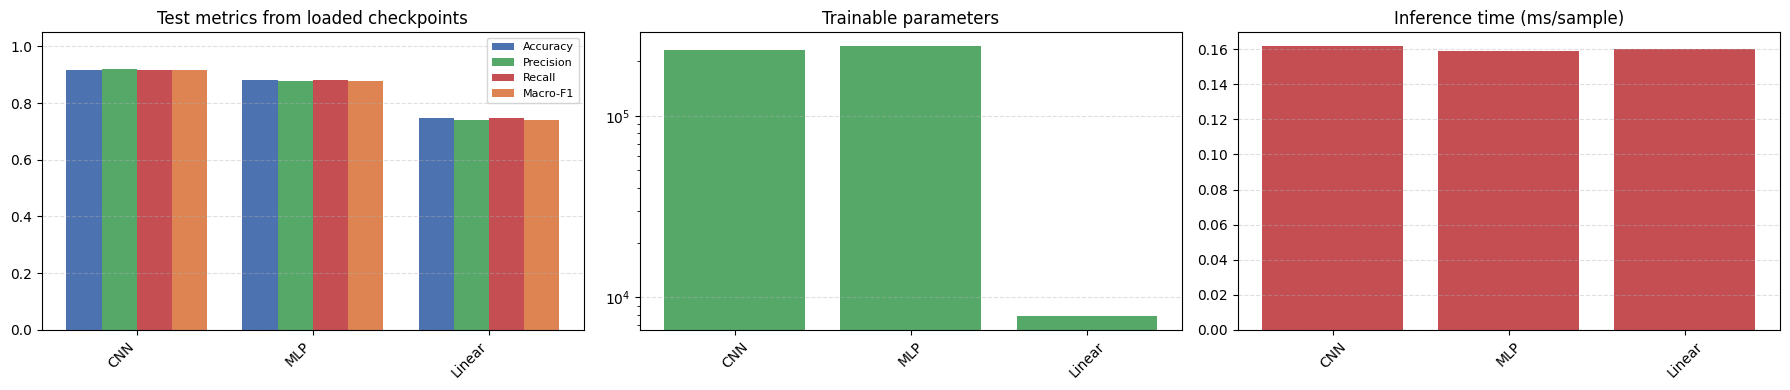

In [30]:
if len(results_df) > 0:
    print(results_df.to_string(index=False))

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    x = np.arange(len(results_df)); width = 0.2
    axes[0].bar(x - 1.5 * width, results_df["test_accuracy_mean"], width, label="Accuracy", color="#4C72B0")
    axes[0].bar(x - 0.5 * width, results_df["test_precision_mean"], width, label="Precision", color="#55A868")
    axes[0].bar(x + 0.5 * width, results_df["test_recall_mean"], width, label="Recall", color="#C44E52")
    axes[0].bar(x + 1.5 * width, results_df["test_macro_f1_mean"], width, label="Macro-F1", color="#DD8452")
    axes[0].set_xticks(x); axes[0].set_xticklabels(results_df["model"], rotation=45, ha="right")
    axes[0].set_title("Test metrics from loaded checkpoints"); axes[0].set_ylim(0, 1.05); axes[0].legend(fontsize=8); axes[0].grid(axis="y", linestyle="--", alpha=0.4)

    axes[1].bar(results_df["model"], results_df["params"], color="#55A868")
    axes[1].set_title("Trainable parameters"); axes[1].set_yscale("log"); axes[1].tick_params(axis="x", rotation=45); axes[1].grid(axis="y", linestyle="--", alpha=0.4)

    axes[2].bar(results_df["model"], results_df["inference_ms_per_sample"], color="#C44E52")
    axes[2].set_title("Inference time (ms/sample)"); axes[2].tick_params(axis="x", rotation=45); axes[2].grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "14_model_comparison.png"), dpi=150, bbox_inches="tight"); plt.show()
else:
    print("No evaluated checkpoint results available.")


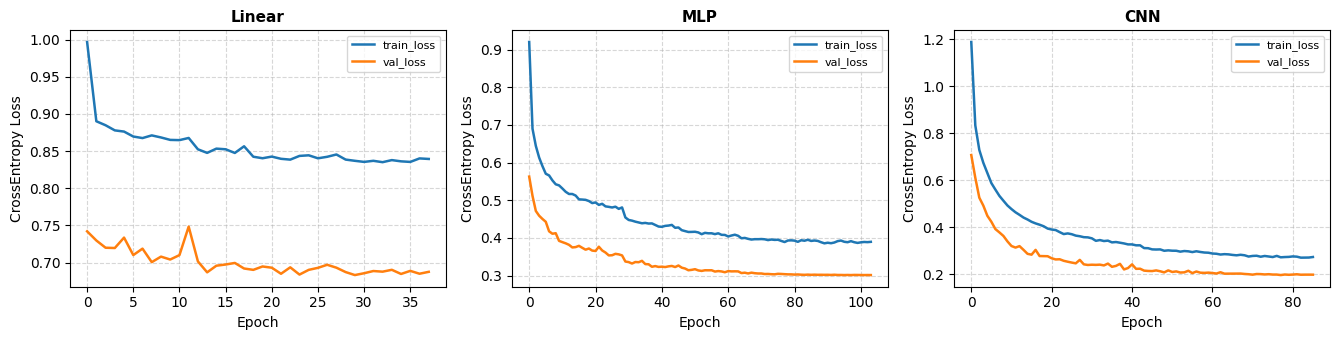

In [31]:
plot_histories = {k: v for k, v in histories.items() if v and "train_loss" in v and len(v["train_loss"]) > 0}
if plot_histories:
    fig, axes = plt.subplots(1, len(plot_histories), figsize=(4.5 * len(plot_histories), 3.5), sharey=False)
    if len(plot_histories) == 1: axes = [axes]
    for ax, (name, h) in zip(axes, plot_histories.items()):
        ax.plot(h["train_loss"], label="train_loss", color="#1f77b4", linewidth=1.8)
        ax.plot(h["val_loss"], label="val_loss", color="#ff7f0e", linewidth=1.8)
        ax.set_title(name, fontsize=11, fontweight="bold"); ax.set_xlabel("Epoch"); ax.set_ylabel("CrossEntropy Loss")
        ax.legend(fontsize=8); ax.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "14_training_curves.png"), dpi=150, bbox_inches="tight"); plt.show()
else:
    print("No history stored in the evaluated checkpoint(s).")


## 15. Confusion matrices


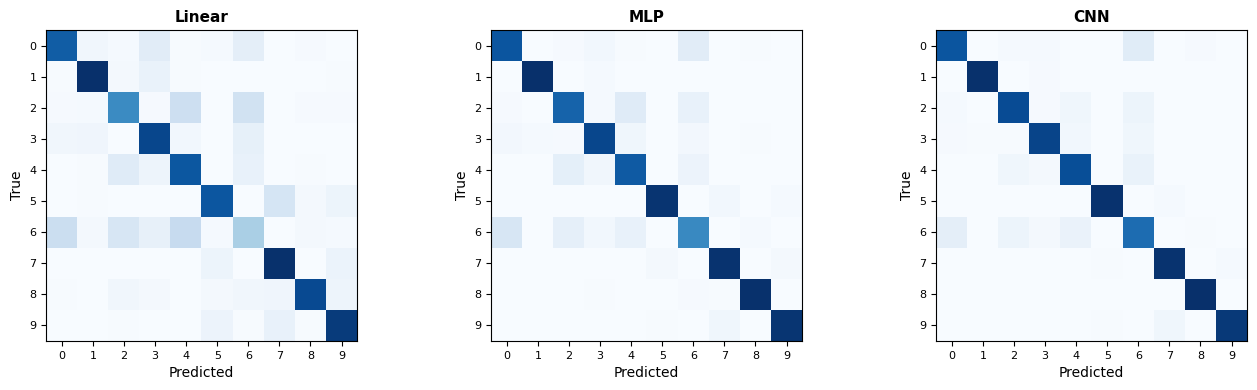

In [32]:
if trained_models:
    fig, axes = plt.subplots(1, len(trained_models), figsize=(4.5 * len(trained_models), 4))
    if len(trained_models) == 1:
        axes = [axes]
    for ax, (name, d) in zip(axes, trained_models.items()):
        cm = confusion_matrix(d["y_true"], d["y_pred"])
        im = ax.imshow(cm, cmap="Blues")
        ax.set_title(name, fontsize=11, fontweight="bold")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_xticks(range(NUM_CLASSES))
        ax.set_yticks(range(NUM_CLASSES))
        ax.set_xticklabels(range(NUM_CLASSES), fontsize=8)
        ax.set_yticklabels(range(NUM_CLASSES), fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "15_confusion_matrices.png"), dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No trained models available for confusion matrix.")


## 16. Qualitative results — correct and incorrect predictions

For the checkpoint with the highest test macro-F1 among `EVAL_MODELS`, show correctly and incorrectly classified Fashion-MNIST examples.


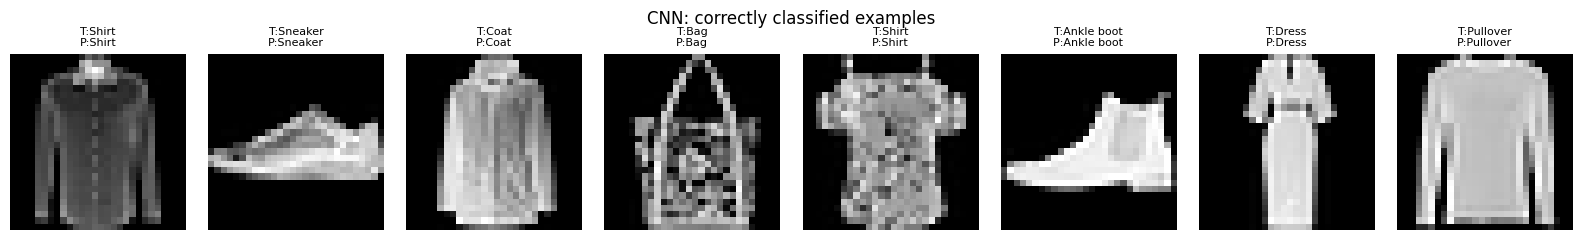

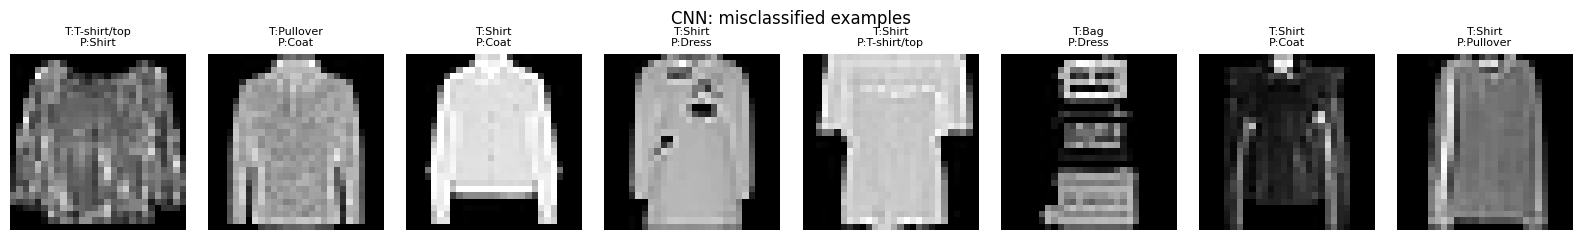

In [33]:
if len(results_df) > 0 and len(trained_models) > 0:
    best_name = results_df.sort_values('test_macro_f1_mean', ascending=False).iloc[0]['model']
    best_model = trained_models[best_name]["model"]
    y_true = trained_models[best_name]["y_true"]
    y_pred = trained_models[best_name]["y_pred"]

    correct_idx = np.where(y_true == y_pred)[0]
    wrong_idx = np.where(y_true != y_pred)[0]

    def show_examples(indices, title, n=8, save_name=None):
        n = min(n, len(indices))
        chosen = np.random.choice(indices, size=n, replace=False) if n > 0 else []
        fig, axes = plt.subplots(1, max(n, 1), figsize=(2 * max(n, 1), 2.4))
        if n == 1:
            axes = [axes]
        for ax, idx in zip(axes, chosen):
            ax.imshow(test_images[idx], cmap="gray")
            ax.set_title(f"T:{CLASS_NAMES[y_true[idx]]}\nP:{CLASS_NAMES[y_pred[idx]]}", fontsize=8)
            ax.axis("off")
        plt.suptitle(title)
        plt.tight_layout()
        if save_name:
            plt.savefig(os.path.join(FIG_DIR, save_name), dpi=150, bbox_inches="tight")
        plt.show()

    show_examples(correct_idx, f"{best_name}: correctly classified examples", save_name="16_qualitative_correct.png")
    show_examples(wrong_idx, f"{best_name}: misclassified examples", save_name="16_qualitative_incorrect.png")
else:
    print("No model results available for qualitative display.")


## 18. Reproducibility

- Split: stratified 48,000 / 12,000 / 10,000 (train/val/test), seed 42.
- Training uses Adam + ReduceLROnPlateau and best-validation-loss early stopping with `PATIENCE=8` in Section 12.
- Checkpoints are stored as `CKPT_DIR/<model>_200K_v3.pt` and contain model weights, history, test metadata, and (for checkpoints created by this final notebook) optimizer/scheduler state.
- Section 13 re-evaluates the checkpoint on the current `test_loader`; it does not rely on metrics left in RAM by training.
- If the architecture changes, use a new `CHECKPOINT_TAG` or retrain instead of loading an incompatible checkpoint.


In [34]:
print("Reproducibility summary")
print("-" * 40)
for k, v in env_info.items(): print(f"{k}: {v}")
print("split: stratified 48,000 / 12,000 / 10,000 (train/val/test — 80/20 train/val)")
print("training_early_stopping_patience:", PATIENCE if "PATIENCE" in globals() else "Section 12 not run")
print("checkpoint_tag:", CHECKPOINT_TAG)
print("checkpoints_dir:", os.path.abspath(CKPT_DIR))
print("checkpoint_files:", sorted(os.listdir(CKPT_DIR)))


Reproducibility summary
----------------------------------------
seed: 42
python_version: 3.13.15
torch_version: 2.11.0+cu128
torchvision_version: 0.26.0+cu128
device: cuda
gpu_name: Tesla T4
platform: Linux-6.6.122+-x86_64-with-glibc2.39
split: stratified 48,000 / 12,000 / 10,000 (train/val/test — 80/20 train/val)
training_early_stopping_patience: 8
checkpoint_tag: 200K_v3
checkpoints_dir: /content/drive/MyDrive/CO3133_Assignments/A1_Foundations_FashionMNIST/checkpoints
checkpoint_files: ['CNN.pt', 'CNN_200K.pt', 'CNN_200K_v2.pt', 'CNN_200K_v3.pt', 'GRU.pt', 'Linear.pt', 'Linear_200K.pt', 'Linear_200K_v2.pt', 'Linear_200K_v3.pt', 'MLP.pt', 'MLP_200K.pt', 'MLP_200K_v2.pt', 'MLP_200K_v3.pt', 'Transformer.pt']


## 19. AI Usage Disclosure (assignment-level)

Fill in one entry per AI tool actually used, following the mandatory fields in Section 5.2 of
the handbook (tool + version, member, stage, purpose, affected sections, prompt summary,
how output was verified, responsible member). If no AI tool was used, replace this cell with:

> The group declares that no generative AI tool was used in this assignment.

| Tool | Used by | Task | Prompt summary | Verification | Responsible member |
|------|---------|------|-----------------|---------------|---------------------|
| TODO | TODO    | TODO | TODO            | TODO          | TODO                |


## 20. Save evaluation artifacts to Google Drive

This cell saves the **evaluation outputs** generated from checkpoints. It does not create a second, differently formatted model checkpoint, avoiding the previous `CNN.pt` vs `CNN_200K_v3.pt` ambiguity.


In [ ]:
if len(results_df) > 0:
    results_csv_path = os.path.join(RESULTS_DIR, "a1_results_summary.csv")
    histories_path = os.path.join(RESULTS_DIR, "a1_histories.pkl")
    preds_path = os.path.join(RESULTS_DIR, "a1_test_predictions.pkl")

    results_df.to_csv(results_csv_path, index=False)
    with open(histories_path, "wb") as f: pickle.dump(histories, f)
    with open(preds_path, "wb") as f:
        pickle.dump({name: {"y_true": d["y_true"], "y_pred": d["y_pred"]} for name, d in trained_models.items()}, f)

    print("Saved:")
    print(" -", results_csv_path)
    print(" -", histories_path)
    print(" -", preds_path)
    print(" -", FIG_DIR, "(figures)")
    print("Model checkpoints remain in:", CKPT_DIR)
else:
    print("Nothing to save: run Section 13 evaluation first.")
